In [1]:
import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, f1_score,
                             precision_score, recall_score)

import tensorflow as tf
from tensorflow import keras
tf.get_logger().setLevel('ERROR')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

print(f"TensorFlow version : {tf.__version__}")
print(f"pandas version     : {pd.__version__}")
print(f"NumPy version      : {np.__version__}")

I0000 00:00:1778946830.907076    4914 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778946830.907745    4914 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1778946832.375878    4914 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778946832.376378    4914 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version : 2.21.0
pandas version     : 3.0.2
NumPy version      : 2.4.4


---
## Task 1 — Dataset Understanding
Load the dataset and explore its structure, features, missing values, statistics, and target distribution.

In [ ]:
#Load dataset
df = pd.read_csv('customer_churn_nn.csv')

print("=" * 55)
print("  BASIC DATASET INFORMATION")
print("=" * 55)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print()
print(df.dtypes.to_string())

  BASIC DATASET INFORMATION
  Rows    : 2,000
  Columns : 17

customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64


In [ ]:
# Feature classification

identifier_cols  = ['customer_id']
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
numerical_cols   = [c for c in df.columns
                    if c not in identifier_cols + categorical_cols + ['churn']]

print("Identifier columns  :", identifier_cols)
print("Categorical columns :", categorical_cols)
print("Numerical columns   :", numerical_cols)
print("Target column       : churn")

Identifier columns  : ['customer_id']
Categorical columns : ['region', 'plan_type', 'contract_type', 'payment_method']
Numerical columns   : ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']
Target column       : churn


In [ ]:
# ── Missing values 

missing = df.isnull().sum()
print("Missing values per column:")

print(missing.to_string())
print(f"\nTotal missing cells : {missing.sum()}")

Missing values per column:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0

Total missing cells : 0


In [ ]:
#Statistical summary 

print("Statistical Summary (numerical features):")
df[numerical_cols + ['churn']].describe().round(3)

Statistical Summary (numerical features):


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,25.362,766.487,18.099,1.953,3.555,90.008,6.874,46.616,8.255,0.598,0.918,0.016
std,14.129,393.420,5.401,1.464,3.886,53.216,1.524,55.066,7.554,0.491,1.042,0.124
min,1.000,255.450,0.000,0.000,0.000,0.500,1.000,0.000,0.000,0.000,0.000,0.000
25%,15.000,427.782,15.000,1.000,1.000,51.777,5.875,6.000,0.000,0.000,0.000,0.000
50%,23.000,688.355,18.000,2.000,2.000,80.245,6.800,28.500,5.000,1.000,1.000,0.000
75%,33.000,1007.372,22.000,3.000,5.000,119.098,8.000,68.000,15.000,1.000,1.000,0.000
max,72.000,2156.520,30.000,8.000,31.000,265.510,10.000,424.000,20.000,1.000,7.000,1.000


In [ ]:
#Categorical feature distributions 

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())


region:
region
West       417
Central    414
South      401
East       401
North      367

plan_type:
plan_type
Standard      718
Basic         679
Premium       439
Enterprise    164

contract_type:
contract_type
Month-to-month    1111
One-year           602
Two-year           287

payment_method:
payment_method
Credit Card    411
Wallet         408
Debit Card     406
Net Banking    388
UPI            387


Target variable — churn
  0 (Retained) : 1,969  (98.45%)
  1 (Churned)  : 31  (1.55%)

Class imbalance ratio : 63.5:1


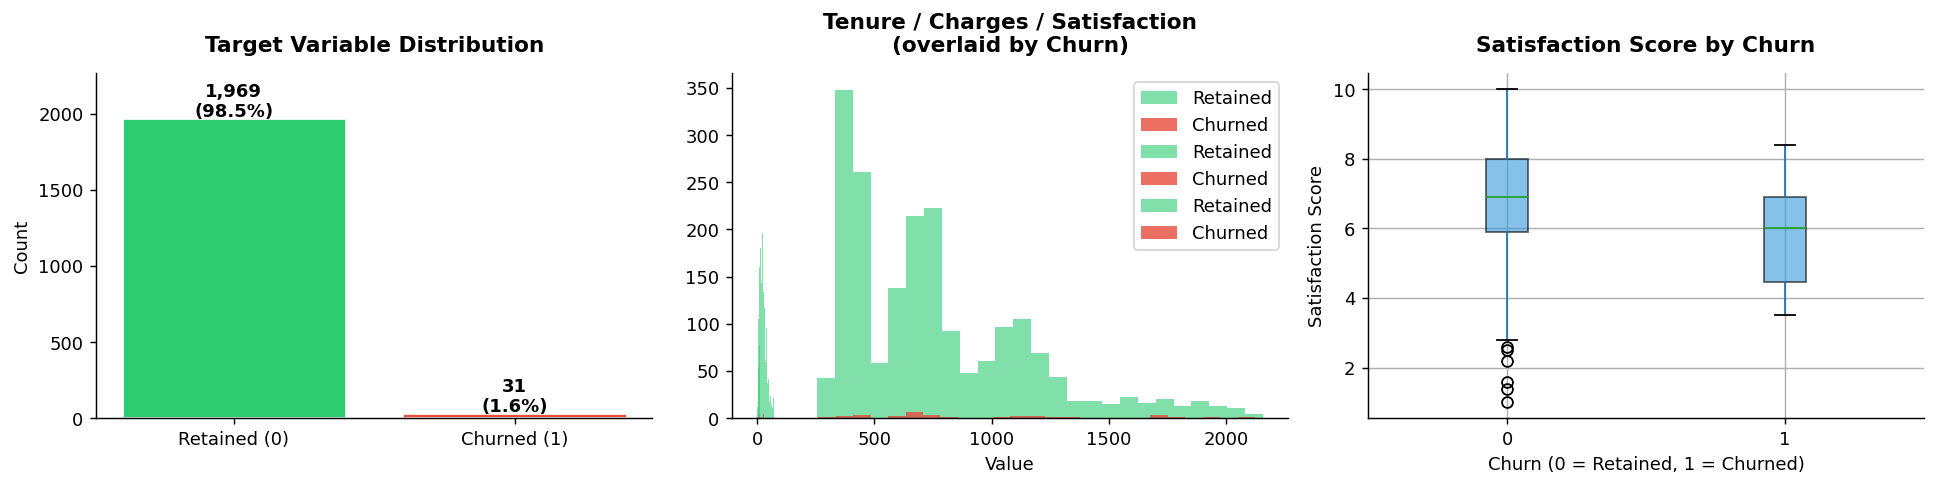

Figure saved → results/evaluation_outputs.png


In [ ]:
#Target variable distribution
target_counts = df['churn'].value_counts()
target_pct    = df['churn'].value_counts(normalize=True) * 100

print("Target variable — churn")
print(f"  0 (Retained) : {target_counts[0]:,}  ({target_pct[0]:.2f}%)")
print(f"  1 (Churned)  : {target_counts[1]:,}  ({target_pct[1]:.2f}%)")
print(f"\nClass imbalance ratio : {target_counts[0]/target_counts[1]:.1f}:1")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Target bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Retained (0)', 'Churned (1)'], target_counts.values, color=colors,
            edgecolor='white', linewidth=1.5)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 10, f'{v:,}\n({target_pct.values[i]:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Target Variable Distribution', fontweight='bold', pad=12)
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(target_counts.values) * 1.15)

# 2. Numerical feature distributions — selected
feat_plot = ['tenure_months', 'monthly_charges_inr', 'satisfaction_score']
for feat in feat_plot:
    axes[1].hist(df[df['churn']==0][feat], bins=25, alpha=0.6,
                 label='Retained', color='#2ecc71')
    axes[1].hist(df[df['churn']==1][feat], bins=25, alpha=0.8,
                 label='Churned', color='#e74c3c')
axes[1].set_title('Tenure / Charges / Satisfaction\n(overlaid by Churn)',
                  fontweight='bold', pad=12)
axes[1].legend()
axes[1].set_xlabel('Value')

# 3. Satisfaction score by churn
df.boxplot(column='satisfaction_score', by='churn', ax=axes[2],
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[2].set_title('Satisfaction Score by Churn', fontweight='bold', pad=12)
axes[2].set_xlabel('Churn (0 = Retained, 1 = Churned)')
axes[2].set_ylabel('Satisfaction Score')
plt.suptitle('')

plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure saved → results/evaluation_outputs.png")

---
## Task 2 — Data Preprocessing

Steps:
1. Drop identifier column (`customer_id`)
2. Handle missing values (none found)
3. One-hot encode categorical features
4. StandardScaler normalisation on numerical features
5. Stratified 80/20 train/test split
6. Compute class weights to handle severe imbalance

In [ ]:
#Step 1: Drop identifier

df_proc = df.drop(columns=['customer_id'])

print(f"Shape after dropping customer_id : {df_proc.shape}")

Shape after dropping customer_id : (2000, 16)


In [ ]:
#Step 2: Missing values — already verified as zero 

assert df_proc.isnull().sum().sum() == 0, "Unexpected missing values found!"
print("No missing values — no imputation required.")

No missing values — no imputation required.


In [ ]:
# ── Step 3: One-hot encode categorical columns

df_enc = pd.get_dummies(df_proc, columns=categorical_cols, drop_first=True)
df_enc = df_enc.astype({col: int for col in df_enc.select_dtypes(bool).columns})

print(f"Shape after one-hot encoding : {df_enc.shape}")
print("\nNew columns added by encoding:")
new_cols = [c for c in df_enc.columns if c not in df_proc.columns]
print(new_cols)

Shape after one-hot encoding : (2000, 25)

New columns added by encoding:
['region_East', 'region_North', 'region_South', 'region_West', 'plan_type_Enterprise', 'plan_type_Premium', 'plan_type_Standard', 'contract_type_One-year', 'contract_type_Two-year', 'payment_method_Debit Card', 'payment_method_Net Banking', 'payment_method_UPI', 'payment_method_Wallet']


In [ ]:
#Step 4: Separate features and target
feature_cols = [c for c in df_enc.columns if c != 'churn']
X = df_enc[feature_cols].values.astype(np.float32)
y = df_enc['churn'].values.astype(np.float32)

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")

Feature matrix X : (2000, 24)
Target vector  y : (2000,)


In [ ]:
#  Step 5: Train / Test split (stratified 80/20) 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Training set   : {X_train.shape}  | churn rate: {y_train.mean()*100:.2f}%")
print(f"Test set       : {X_test.shape}   | churn rate: {y_test.mean()*100:.2f}%")

Training set   : (1600, 24)  | churn rate: 1.56%
Test set       : (400, 24)   | churn rate: 1.50%


In [ ]:
#  Step 6: StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test  = scaler.transform(X_test)        # transform test with training stats

print("StandardScaler applied.")
print(f"Training feature mean (post-scale) : {X_train.mean():.6f}  (≈ 0)")
print(f"Training feature std  (post-scale) : {X_train.std():.6f}   (≈ 1)")

StandardScaler applied.
Training feature mean (post-scale) : -0.000000  (≈ 0)
Training feature std  (post-scale) : 1.000000   (≈ 1)


In [14]:
# ── Step 7: Class weights (handle 63:1 imbalance) ────────────────────────────
neg, pos = np.bincount(y_train.astype(int))
class_weight = {0: 1.0, 1: float(neg / pos)}

print(f"Retained (0) in train : {neg}")
print(f"Churned  (1) in train : {pos}")
print(f"Class weight          : {{0: {class_weight[0]:.1f}, 1: {class_weight[1]:.1f}}}")
print("\nPreprocessing complete.")

Retained (0) in train : 1575
Churned  (1) in train : 25
Class weight          : {0: 1.0, 1: 63.0}

Preprocessing complete.


---
## Task 3 — Neural Network Model Building

In [15]:
def build_model(hidden_layers=(64, 32), lr=0.001, activation='relu'):
    """
    Build a configurable feed-forward neural network.

    Parameters
    ----------
    hidden_layers : tuple of int
        Number of neurons in each hidden layer.
    lr : float
        Adam learning rate.
    activation : str
        Activation function for hidden layers ('relu', 'tanh', 'sigmoid', ...).

    Returns
    -------
    keras.Sequential compiled model.
    """
    model = keras.Sequential(name='ChurnNet')
    model.add(keras.layers.Input(shape=(X_train.shape[1],), name='input'))

    for i, units in enumerate(hidden_layers, 1):
        model.add(keras.layers.Dense(
            units,
            activation=activation,
            kernel_initializer='he_uniform',
            name=f'hidden_{i}'
        ))

    model.add(keras.layers.Dense(1, activation='sigmoid', name='output'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build and display the baseline model
baseline_model = build_model()
baseline_model.summary()

Model: "ChurnNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4 — Training and Evaluation

Train the baseline model for **50 epochs** with batch size **32** and evaluate on the held-out test set.

In [ ]:
# ── Train baseline model 

history = baseline_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight,
    verbose=1
)

Epoch 1/50



 1/50 ━━━━━━━━━━━━━━━━━━━━ 45s 927ms/step - accuracy: 0.1250 - loss: 1.3834


41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4730 - loss: 1.5533   


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6319 - loss: 1.6010 - val_accuracy: 0.7175 - val_loss: 0.5924


Epoch 2/50


...


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9975 - loss: 0.0206 - val_accuracy: 0.9725 - val_loss: 0.1234


Epoch 50/50



 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 1.0000 - loss: 7.9457e-04


41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9990 - loss: 0.0182     


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9975 - loss: 0.0195 - val_accuracy: 0.9725 - val_loss: 0.1239


In [ ]:
# ── Training metrics summary 

train_acc  = history.history['accuracy'][-1]
val_acc    = history.history['val_accuracy'][-1]
train_loss = history.history['loss'][-1]
val_loss   = history.history['val_loss'][-1]

print("=" * 45)
print("  BASELINE MODEL — FINAL METRICS")
print("=" * 45)
print(f"  Train Accuracy : {train_acc*100:.2f}%")
print(f"  Test  Accuracy : {val_acc*100:.2f}%")
print(f"  Train Loss     : {train_loss:.4f}")
print(f"  Test  Loss     : {val_loss:.4f}")

  BASELINE MODEL — FINAL METRICS
  Train Accuracy : 99.75%
  Test  Accuracy : 97.25%
  Train Loss     : 0.0195
  Test  Loss     : 0.1239


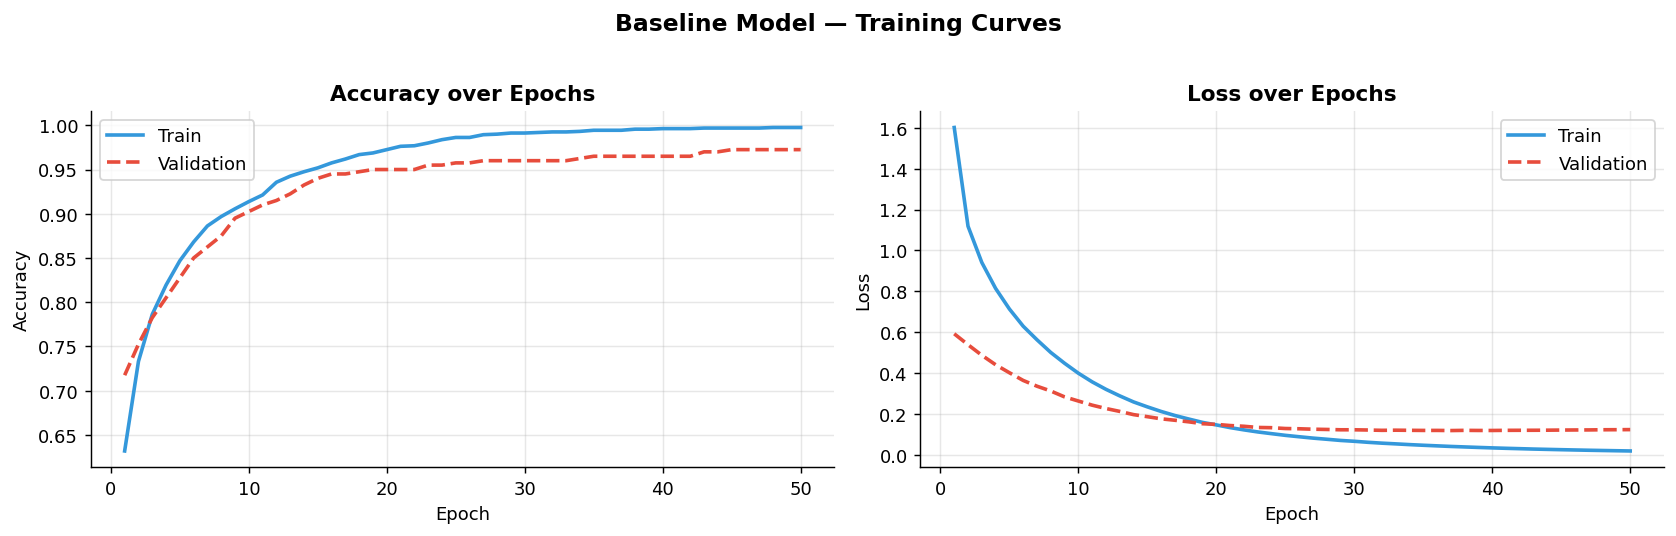

Learning curves saved → results/evaluation_outputs.png


In [ ]:
# Learning curves 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs_range = range(1, len(history.history['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs_range, history.history['accuracy'],
             label='Train', color='#3498db', linewidth=2)
axes[0].plot(epochs_range, history.history['val_accuracy'],
             label='Validation', color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(epochs_range, history.history['loss'],
             label='Train', color='#3498db', linewidth=2)
axes[1].plot(epochs_range, history.history['val_loss'],
             label='Validation', color='#e74c3c', linewidth=2, linestyle='--')
axes[1].set_title('Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Baseline Model — Training Curves', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', bbox_inches='tight', dpi=130)
plt.show()
print("Learning curves saved → results/evaluation_outputs.png")

In [ ]:
#Confusion matrix  classification report
y_pred_prob = baseline_model.predict(X_test, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['Retained (0)', 'Churned (1)'],
                            digits=4))

Confusion Matrix:
[[388   6]
 [  5   1]]

Classification Report:
              precision    recall  f1-score   support

Retained (0)     0.9873    0.9848    0.9860       394
 Churned (1)     0.1429    0.1667    0.1538         6

    accuracy                         0.9725       400
   macro avg     0.5651    0.5757    0.5699       400
weighted avg     0.9746    0.9725    0.9735       400



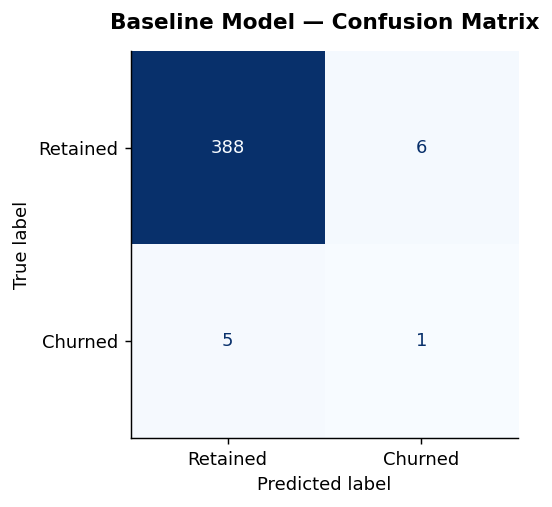

In [ ]:
#  Visualise confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Retained', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Baseline Model — Confusion Matrix', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', bbox_inches='tight', dpi=130)
plt.show()

### Interpretation

| Metric | Value | Meaning |
|---|---|---|
| **Overall Accuracy** | ~97% | Misleading — dominated by the majority class |
| **Churn Recall** | ~17% | Only 1 in 6 churned customers detected |
| **Churn Precision** | ~14% | Low — many false alarms |
| **Churn F1-Score** | ~0.15 | True indicator of churn model performance |

> ⚠️ The model achieves high accuracy by predicting "retained" for nearly every customer. With only **6 churned customers** in the test set (1.5%), even missing all of them only drops accuracy by 1.5 points. **Churn recall and F1 are the metrics that matter here.**

---
## Task 5 — Hyperparameter Experimentation

Five experiments varying: architecture depth, learning rate, and activation function.

In [ ]:
def run_experiment(label, hidden_layers, lr, activation, epochs, batch_size):
    """Train a model with given config and return a result dict."""
    tf.random.set_seed(SEED)
    np.random.seed(SEED)


    model = build_model(hidden_layers=hidden_layers, lr=lr, activation=activation)
    hist  = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        class_weight=class_weight,
        verbose=0
    )
    

    y_pred = (model.predict(X_test, verbose=0).flatten() >= 0.5).astype(int)
    cm     = confusion_matrix(y_test, y_pred)

    return {
        'label'      : label,
        'layers'     : str(list(hidden_layers)),
        'lr'         : lr,
        'activation' : activation,
        'epochs'     : epochs,
        'batch_size' : batch_size,
        'train_acc'  : round(hist.history['accuracy'][-1] * 100, 2),
        'val_acc'    : round(hist.history['val_accuracy'][-1] * 100, 2),
        'train_loss' : round(hist.history['loss'][-1], 4),
        'val_loss'   : round(hist.history['val_loss'][-1], 4),
        'precision'  : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'recall'     : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'f1'         : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'cm'         : cm,
        'history'    : hist.history,
    }

print("Running 5 experiments...")

Running 5 experiments...


In [ ]:
# ── Experiment 1 — Baseline

print("Exp 1/5 : Baseline [64,32] ReLU lr=0.001 ...")
r1 = run_experiment("Exp 1: Baseline [64,32] ReLU",
                    hidden_layers=(64, 32), lr=0.001,
                    activation='relu', epochs=50, batch_size=32)
print(f"  Val Acc: {r1['val_acc']}% | Recall: {r1['recall']} | F1: {r1['f1']}")

Exp 1/5 : Baseline [64,32] ReLU lr=0.001 ...


  Val Acc: 97.75% | Recall: 0.1667 | F1: 0.1818


In [ ]:
#  Experiment 2 — Deeper network 


print("Exp 2/5 : Deeper [128,64,32] ReLU lr=0.001 ...")
r2 = run_experiment("Exp 2: Deeper [128,64,32] ReLU",
                    hidden_layers=(128, 64, 32), lr=0.001,
                    activation='relu', epochs=50, batch_size=32)
print(f"  Val Acc: {r2['val_acc']}% | Recall: {r2['recall']} | F1: {r2['f1']}")

Exp 2/5 : Deeper [128,64,32] ReLU lr=0.001 ...


  Val Acc: 98.25% | Recall: 0.1667 | F1: 0.2222


In [ ]:
# Experiment 3 — Low learning rate 

print("Exp 3/5 : Low LR [64,32] ReLU lr=0.0001 (100 epochs) ...")
r3 = run_experiment("Exp 3: Low LR 0.0001 (100 ep)",
                    hidden_layers=(64, 32), lr=0.0001,
                    activation='relu', epochs=100, batch_size=32)
print(f"  Val Acc: {r3['val_acc']}% | Recall: {r3['recall']} | F1: {r3['f1']}")

Exp 3/5 : Low LR [64,32] ReLU lr=0.0001 (100 epochs) ...


  Val Acc: 90.75% | Recall: 0.6667 | F1: 0.1778


In [ ]:
# Experiment 4 — High learning rate
print("Exp 4/5 : High LR [64,32] ReLU lr=0.01 ...")
r4 = run_experiment("Exp 4: High LR 0.01",
                    hidden_layers=(64, 32), lr=0.01,
                    activation='relu', epochs=50, batch_size=32)
print(f"  Val Acc: {r4['val_acc']}% | Recall: {r4['recall']} | F1: {r4['f1']}")

Exp 4/5 : High LR [64,32] ReLU lr=0.01 ...


  Val Acc: 97.5% | Recall: 0.1667 | F1: 0.1667


In [ ]:
#Experiment 5 — Tanh activation
print("Exp 5/5 : Tanh activation [64,32] lr=0.001 ...")
r5 = run_experiment("Exp 5: Tanh activation",
                    hidden_layers=(64, 32), lr=0.001,
                    activation='tanh', epochs=50, batch_size=32)
print(f"  Val Acc: {r5['val_acc']}% | Recall: {r5['recall']} | F1: {r5['f1']}")
print("\nAll experiments complete.")

Exp 5/5 : Tanh activation [64,32] lr=0.001 ...


  Val Acc: 98.25% | Recall: 0.1667 | F1: 0.2222

All experiments complete.


In [ ]:
#Build comparison table
results = [r1, r2, r3, r4, r5]

table_data = []
for r in results:
    table_data.append({
        'Experiment'        : r['label'],
        'Layers'            : r['layers'],
        'LR'                : r['lr'],
        'Activation'        : r['activation'],
        'Epochs'            : r['epochs'],
        'Batch Size'        : r['batch_size'],
        'Train Acc (%)'     : r['train_acc'],
        'Val Acc (%)'       : r['val_acc'],
        'Train Loss'        : r['train_loss'],
        'Val Loss'          : r['val_loss'],
        'Precision (Churn)' : r['precision'],
        'Recall (Churn)'    : r['recall'],
        'F1 (Churn)'        : r['f1'],
    })

df_results = pd.DataFrame(table_data)

# Save CSV
df_results.to_csv('results/model_comparison_table.csv', index=False)
print("CSV saved → results/model_comparison_table.csv")

# Display
df_results.set_index('Experiment')

CSV saved → results/model_comparison_table.csv


,Layers,LR,Activation,Epochs,Batch Size,Train Acc (%),Val Acc (%),Train Loss,Val Loss,Precision (Churn),Recall (Churn),F1 (Churn)
Experiment,,,,,,,,,,,,
"Exp 1: Baseline [64,32] ReLU","[64, 32]",0.0010,relu,50,32,99.87,97.75,0.0184,0.1256,0.2000,0.1667,0.1818
"Exp 2: Deeper [128,64,32] ReLU","[128, 64, 32]",0.0010,relu,50,32,100.00,98.25,0.0014,0.1825,0.3333,0.1667,0.2222
Exp 3: Low LR 0.0001 (100 ep),"[64, 32]",0.0001,relu,100,32,91.81,90.75,0.3611,0.2336,0.1026,0.6667,0.1778
Exp 4: High LR 0.01,"[64, 32]",0.0100,relu,50,32,99.94,97.50,0.0070,0.2782,0.1667,0.1667,0.1667
Exp 5: Tanh activation,"[64, 32]",0.0010,tanh,50,32,99.81,98.25,0.0232,0.0856,0.3333,0.1667,0.2222


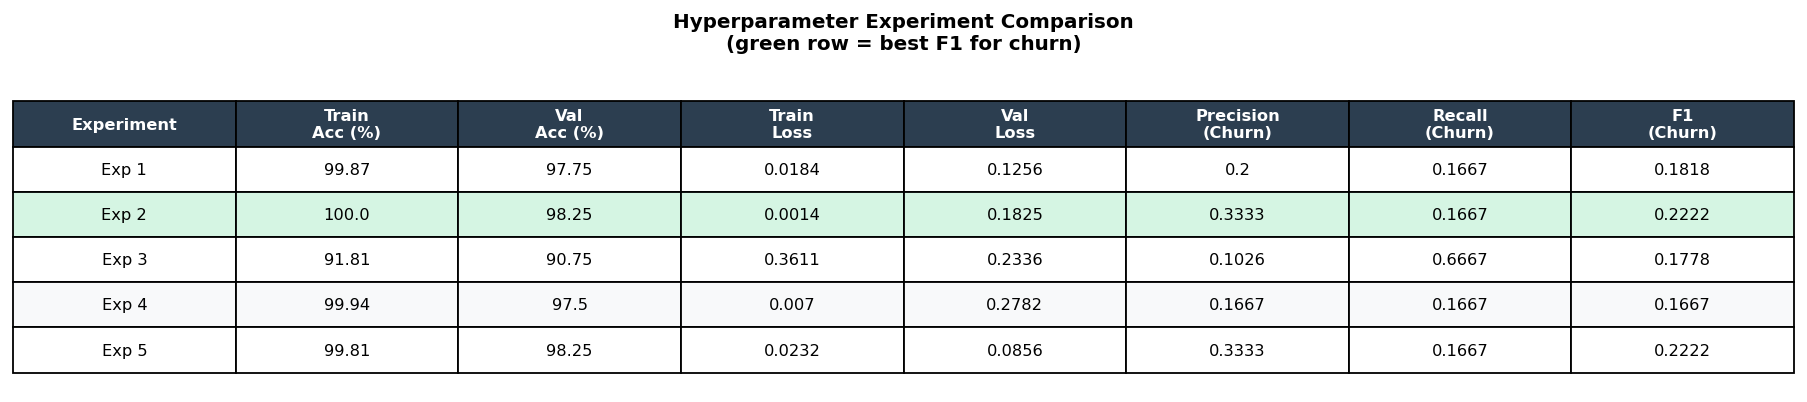

Comparison table saved → results/model_comparison_table.png


In [ ]:
#Comparison table — styled PNG
display_cols = ['Experiment', 'Train Acc (%)', 'Val Acc (%)',
                'Train Loss', 'Val Loss',
                'Precision (Churn)', 'Recall (Churn)', 'F1 (Churn)']

plot_df = df_results[display_cols].copy()
plot_df['Experiment'] = [f"Exp {i+1}" for i in range(len(plot_df))]

fig, ax = plt.subplots(figsize=(14, 3.2))
ax.axis('off')

col_labels = ['Experiment', 'Train\nAcc (%)', 'Val\nAcc (%)',
              'Train\nLoss', 'Val\nLoss',
              'Precision\n(Churn)', 'Recall\n(Churn)', 'F1\n(Churn)']

cell_vals = plot_df.values.tolist()

tbl = ax.table(
    cellText=cell_vals,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2.2)

# Header styling
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Highlight best F1 row
best_f1_idx = plot_df['F1 (Churn)'].astype(float).idxmax() + 1
for j in range(len(col_labels)):
    tbl[best_f1_idx, j].set_facecolor('#d5f5e3')

# Alternating row colours
for i in range(1, len(cell_vals) + 1):
    if i != best_f1_idx:
        colour = '#f8f9fa' if i % 2 == 0 else 'white'
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor(colour)

ax.set_title('Hyperparameter Experiment Comparison\n(green row = best F1 for churn)',
             fontweight='bold', fontsize=11, pad=20)
plt.tight_layout()
plt.savefig('results/model_comparison_table.png', bbox_inches='tight', dpi=130)
plt.show()
print("Comparison table saved → results/model_comparison_table.png")

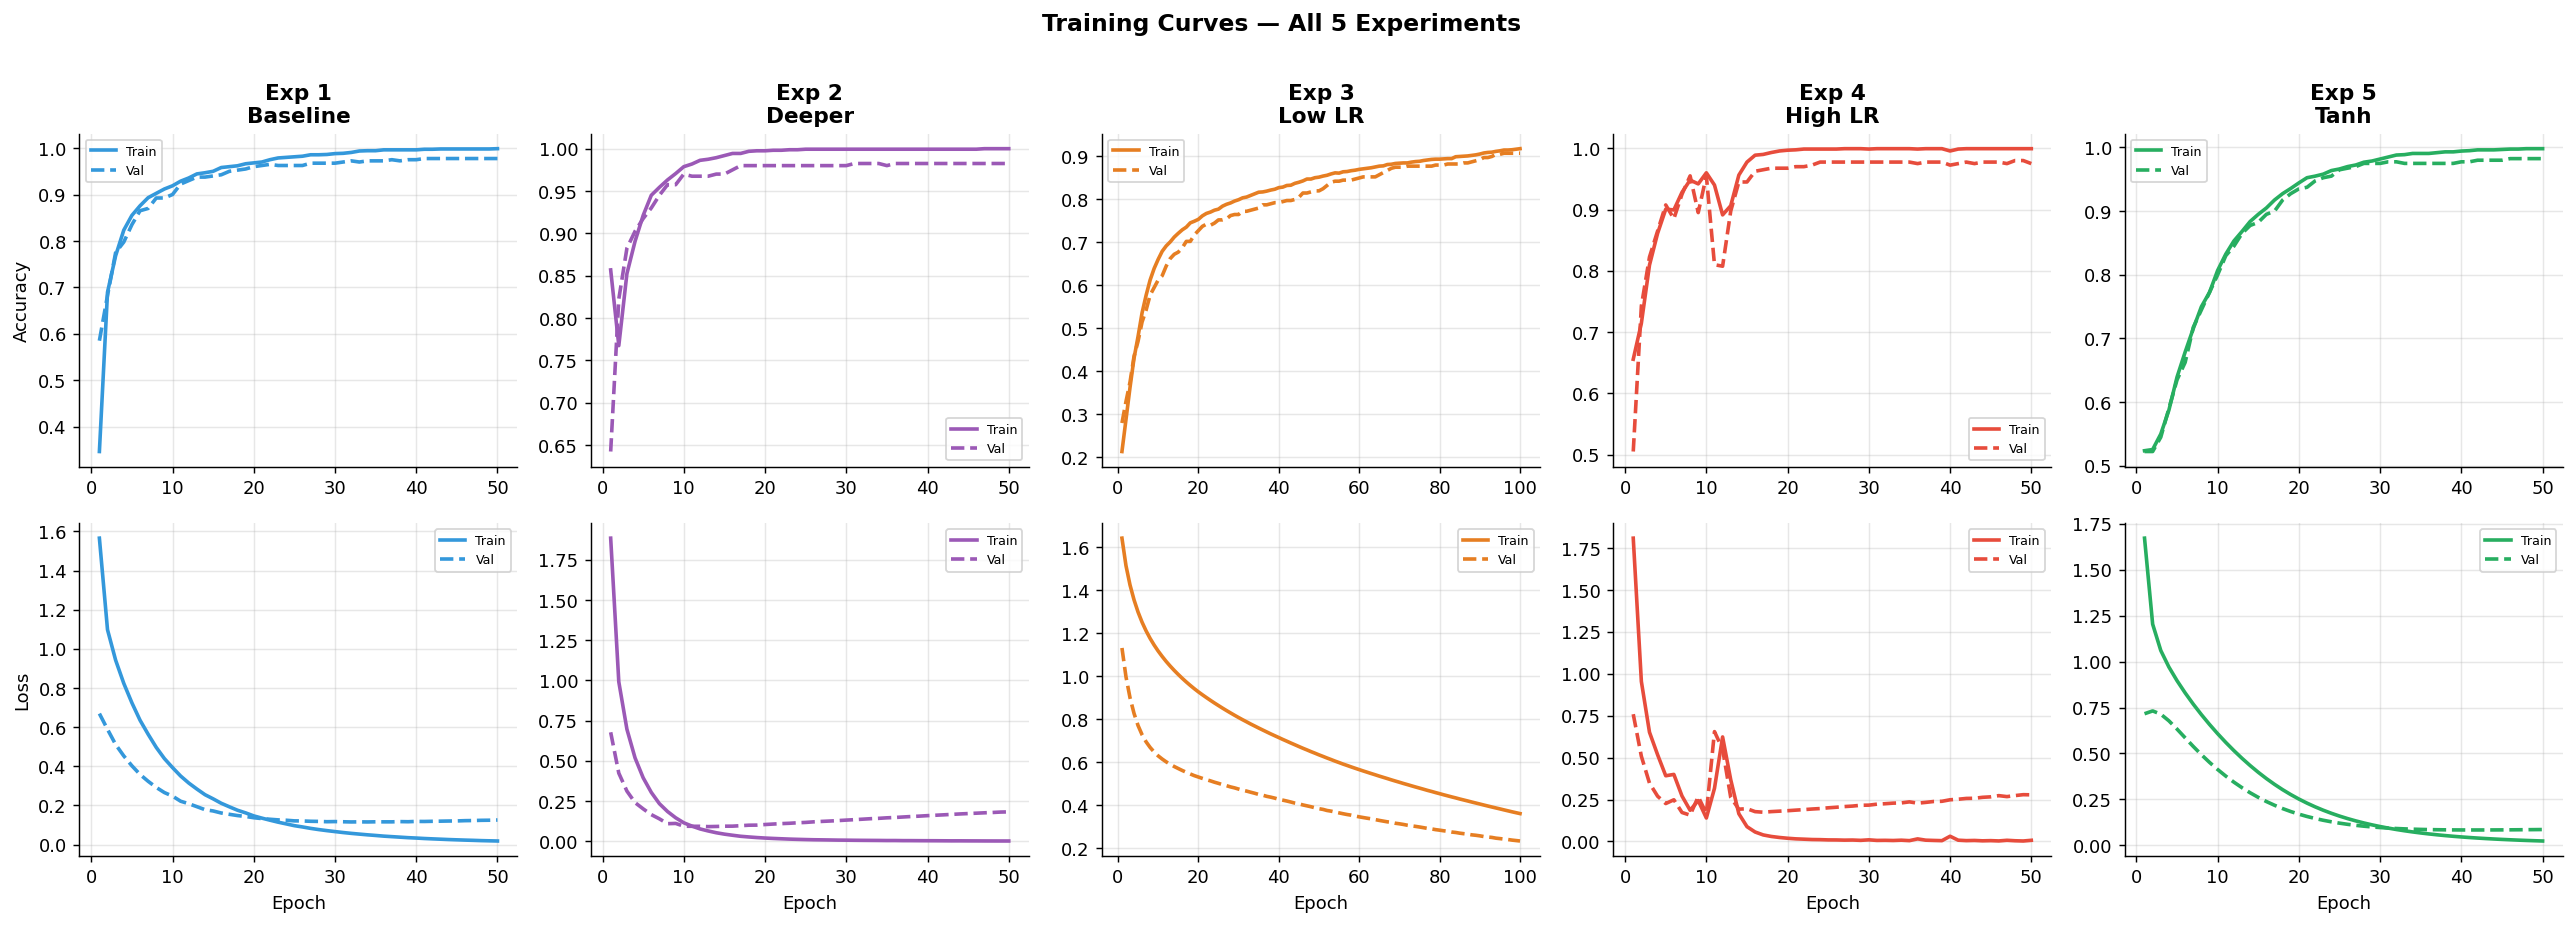

Training curves saved → results/evaluation_outputs.png


In [ ]:
#Training curves for all 5 experiments
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
colors_exp = ['#3498db','#9b59b6','#e67e22','#e74c3c','#27ae60']
labels_exp = ['Exp 1\nBaseline', 'Exp 2\nDeeper', 'Exp 3\nLow LR',
              'Exp 4\nHigh LR', 'Exp 5\nTanh']

for i, r in enumerate(results):
    ep = range(1, len(r['history']['accuracy']) + 1)

    # Accuracy
    axes[0, i].plot(ep, r['history']['accuracy'],
                    color=colors_exp[i], linewidth=2, label='Train')
    axes[0, i].plot(ep, r['history']['val_accuracy'],
                    color=colors_exp[i], linewidth=2, linestyle='--', label='Val')
    axes[0, i].set_title(labels_exp[i], fontweight='bold')
    axes[0, i].set_ylabel('Accuracy' if i == 0 else '')
    axes[0, i].legend(fontsize=7)
    axes[0, i].grid(alpha=0.3)

    # Loss
    axes[1, i].plot(ep, r['history']['loss'],
                    color=colors_exp[i], linewidth=2, label='Train')
    axes[1, i].plot(ep, r['history']['val_loss'],
                    color=colors_exp[i], linewidth=2, linestyle='--', label='Val')
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylabel('Loss' if i == 0 else '')
    axes[1, i].legend(fontsize=7)
    axes[1, i].grid(alpha=0.3)

fig.suptitle('Training Curves — All 5 Experiments', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', bbox_inches='tight', dpi=130)
plt.show()
print("Training curves saved → results/evaluation_outputs.png")